""" UIDAI Data Hackathon 2026 Problem Statement: Unlocking Societal Trends in Aadhaar Enrolment and Updates.

The objective is to identify meaningful patterns, societal trends, regional disparities, anomalies, and predictive indicators in Aadhaar enrolment and update activities. The analysis aims to support data-driven decision making and operational improvements by uncovering actionable insights across states, districts, age groups, and time periods.

Dataset:
- Aadhaar Enrolment dataset: It includes variables such as the date of enrollment, state, district, PIN code, and age-wise categories (age_0_5, age_5_17, and age_18_greater)
- Aadhaar Demographic Update dataset: It includes variables such as the date, state, district, PIN code, and age-wise categories (demo_age_5_17, demo_age_17_) """

In [2]:
# ============================================================================
# SECTION 1: SETUP AND IMPORTS
# ============================================================================

import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import glob

from scipy import stats
from datetime import datetime
from scipy.stats import pearsonr

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [3]:
# ============================================================================
# SECTION 2: DATA LOADING AND INITIAL EXPLORATION
# ============================================================================

def load_csv_files(path_pattern, **read_csv_kwargs):
    files = glob.glob(path_pattern)
    if not files:
        raise FileNotFoundError(f"No CSV files found for pattern: {path_pattern}")

    df = pd.concat(
        (pd.read_csv(f, **read_csv_kwargs) for f in files),
        ignore_index=True
    )
    return df    

enrol_data = load_csv_files(r"~\Adhar\Enrol\DataFiles\*.csv")
update_data = load_csv_files( r"~\Adhar\Demog\DataFiles\*.csv")

In [4]:
print(f"✓ Enrollment data loaded: {enrol_data.shape[0]} records, {enrol_data.shape[1]} columns")
print(f"✓ Unique states and district in Enrollment data before cleaning: {enrol_data["state"].nunique()} states, {enrol_data["district"].nunique()} districts")

print(f"✓ Update data loaded: {update_data.shape[0]} records, {update_data.shape[1]} columns")
print(f"✓ Unique states and district in update data before cleaning: {update_data["state"].nunique()} states, {update_data["district"].nunique()} districts")

✓ Enrollment data loaded: 1006029 records, 7 columns
✓ Unique states and district in Enrollment data before cleaning: 55 states, 985 districts
✓ Update data loaded: 2071700 records, 6 columns
✓ Unique states and district in update data before cleaning: 65 states, 983 districts


# Aadhaar Cleaning Pipeline
Its a generic cleaning pipeline used for both Enrol & Update dataset.

Step 1: Provide lookup path
- Used lookup files for proper mapping of state and district.

Step 2: Phase A - Normalize and apply_regex_cleanup  state and district names
- Strip spaces from state/district names
- Convert to uppercase for consistency
- Convert to string
- replace special characters with space

Step 3: Phase B - remove invalid records and drop records
- Excluded records where the district field was "100000".
- Excluded records where the district field contained "?".
- Eliminated each record in which all age group columns (age_0_5, age_5_17, age_18_greater) had values equal to 0.

Step 4: Phase C - State and district standardisation was performed using external lookup tables to ensure consistency and ease of maintenance across datasets.
- apply_state_override – Standardize state names by aligning them with official nomenclature.
- apply_district_state_override – Ensure accurate mapping of districts to their respective states, particularly for newly formed states.
- apply_district_alias – Replace district names with their official designations to maintain consistency.

Step 5: Phase D - Date parsing and removing duplicates
 - Date fields are inconsistent, with entries in both MM-DD-YYYY and YYYY/MM/DD formats
 - Drop duplicates

Step 6: Master Pipeline
- Cleaning and transformation functions are called in sequence

In [6]:
# ============================================================================
# SECTION 3: DATA CLEANING AND PREPROCESSING
# ============================================================================

class AadhaarCleaningPipeline:

    def __init__(self, lookup_path):
        self.state_override = pd.read_csv(f"{lookup_path}/state_override.csv", encoding="latin1")
        self.district_alias = pd.read_csv(f"{lookup_path}/district_alias.csv", encoding="latin1")
        self.district_state_override = pd.read_csv(f"{lookup_path}/district_state_override.csv", encoding="latin1")

# -------------------- Phase A --------------------
    def normalize_text(self, df):
       
        for col in ["state", "district"]:
            df[col] = (
                df[col]
                .astype(str)
                .str.upper()
                .str.strip()
                .str.replace(r"\s*\*$", " ", regex=True)
                .str.strip()
            )
        return df

    def apply_regex_cleanup(self, df):
        df["district"] = (
            df["district"]
            .apply(lambda x: unicodedata.normalize("NFKD", x))
            .str.encode("ascii", "ignore")
            .str.decode("ascii")
            )
        return df
        
# -------------------- Phase B --------------------
        
    def remove_invalid_name_records(self, df):
        if "district" in df.columns:
            df = df[(df["district"] != "100000") & (df["district"] != "?")]
        return df 

    def drop_rows_all_age_zero(self,df):
            # Select only columns that start with "age"
        age_cols = [col for col in df.columns if "age_" in col]

            # Keep rows where NOT all age columns are zero
        return df[~(df[age_cols].eq(0).all(axis=1))]

# -------------------- Phase C --------------------
    ''' Override state names to ensure consistency with official nomenclature.Example:'PONDICHERRY' → 'PUDUCHERRY', 'ORISSA' → 'ODISHA' '''  

    def apply_state_override(self, df): 

        vc_before = df["state"].value_counts()
        print(f"✓ Before override: ORISSA-{vc_before.get('ORISSA', 0)}, ODISHA-{vc_before.get('ODISHA', 0)}")
        
        df = df.merge(
            self.state_override,
            how="left",
            left_on="state",
            right_on="raw_state"
        )
       
        df["state_final"] = df["override_state"].fillna(df["state"])
        df["state"] = df["state_final"]

        vc_after = df["state"].value_counts()
        print(f"✓ After override: ORISSA-{vc_after.get('ORISSA', 0)}, ODISHA-{vc_after.get('ODISHA', 0)}")
        
        return df.drop(columns=["raw_state", "override_state","state_final"])

    ''' Correct district–state mappings using override rules, e.g., overriding 'ANDHRA PRADESH' to 'TELANGANA' 
        for districts like Hyderabad and Nalgonda'''      
    def apply_district_state_override(self, df):
                 
        unique_states_before = df.loc[df["district"] == "NALGONDA", "state"].unique()
        print(f"✓ Before applying override the district 'NALGONDA' mapped to the following states -{unique_states_before}")
       
        df = df.merge(
            self.district_state_override,
            how="left",
            left_on="district",
            right_on="district_updatestate"
        )

        df["state"] = df["override_state"].fillna(df["state"])

        unique_states_after = df.loc[df["district"] == "NALGONDA", "state"].unique()
        print(f"✓ After applying override the district 'NALGONDA' mapped to the following states -{unique_states_after}")

        return df.drop(columns=["override_state","district_updatestate"])

        
    ''' Assign district aliases based on state-specific rules.For instance, map 'Aurangabad' to its alias only in Maharashtra,
    without affecting the same district name in Bihar.similarly alias applied MYSORE to MYSURU  '''      
    def apply_district_alias(self, df):
       
         # validation - Verify Maharashtra Aurangabad only
        mask = (df['state'] == 'MAHARASHTRA') & (
            df['district'].str.contains('AURANGABAD', case=False, na=False))
        filtered_df = df.loc[mask]
        print(f"✓ Before applying district alias check the count of district 'AURANGABAD' in state 'MAHARASHTRA': {len(filtered_df)}")
         
        df = df.merge(
            self.district_alias,
            how="left",
            left_on=["state", "district"],
            right_on=["lookup_state", "raw_district"])        

        df["district_norm"] = df["district_norm"].fillna(df["district"])    
        df["district"] = df["district_norm"]
        df = df.drop(columns=["lookup_state", "raw_district","district_norm"])

         # Validation - Check Bihar Aurangabad remains unchanged
        mask1 = (df['state'] == 'BIHAR') & (
            df['district'].str.contains('CHHATRAPATI SAMBHAJINAGAR', case=False, na=False))
        filtered_df1 = df.loc[mask1]
        print(f"✓ After applying district alias check the count of district 'CHHATRAPATI SAMBHAJINAGAR' in state 'BIHAR': {len(filtered_df1)}")

        mask2 = (df['state'] == 'MAHARASHTRA') & (
            df['district'].str.contains('AURANGABAD', case=False, na=False))
        filtered_df2 = df.loc[mask2] 
        print(f"✓ After applying district alias check the count of district 'AURANGABAD' in state 'MAHARASHTRA': {len(filtered_df2)}")
    
        return df

# -------------------- Phase D --------------------
    def cast_datatypes(self, df):

        df["date"] = (
            df["date"]
            .astype(str)
            .str.strip()
            .replace(["", "NA", "NaN", "null", "None"], pd.NA)
            .str.replace("-", "/", regex=False) )
        
        df["date"] = pd.to_datetime(
            df["date"],
            format="%d/%m/%Y",
            errors="coerce" )

        # Clean state and district names
        for col in ['state', 'district']:
            df[col] = df[col].str.strip().str.title()
            
        return df

    def remove_duplicates(self, df):
        df = df.drop_duplicates()
        print(f"✓ Data after cleaning: {df.shape[0]} records, {df.shape[1]} columns")
        print(f"✓ Unique states and district in Enrollment data after cleaning: {df["state"].nunique()} states, {df["district"].nunique()} districts")
        
        return df

# -------------------- MASTER PIPELINE --------------------
   
    def run(self, df):
        df = df.copy()
        
        df = self.normalize_text(df)
        df = self.apply_regex_cleanup(df)
   
        df = self.remove_invalid_name_records(df)
        df = self.drop_rows_all_age_zero(df)
    
        df = self.apply_state_override(df)
        df = self.apply_district_state_override(df)
        df = self.apply_district_alias(df)
    
        df = self.cast_datatypes(df)
        df = self.remove_duplicates(df)
        return df

In [7]:
# provide lookup file path while calling the AadhaarCleaningPipeline
pipeline = AadhaarCleaningPipeline(r"~\DA\Adhar")

print("************************ Enrol data cleaning process start ************************")
enrol_clean = pipeline.run(enrol_data)
print("------------------------- Enrol data cleaning process end -------------------------")
print("************************ Update data cleaning process start ************************")
update_clean = pipeline.run(update_data)
print("------------------------- Update data cleaning process end -------------------------")

************************ Enrol data cleaning process start ************************
✓ Before override: ORISSA-3319, ODISHA-43692
✓ After override: ORISSA-0, ODISHA-47011
✓ Before applying override the district 'NALGONDA' mapped to the following states -<ArrowStringArray>
['ANDHRA PRADESH', 'TELANGANA']
Length: 2, dtype: str
✓ After applying override the district 'NALGONDA' mapped to the following states -<ArrowStringArray>
['TELANGANA']
Length: 1, dtype: str
✓ Before applying district alias check the count of district 'AURANGABAD' in state 'MAHARASHTRA': 2229
✓ After applying district alias check the count of district 'CHHATRAPATI SAMBHAJINAGAR' in state 'BIHAR': 0
✓ After applying district alias check the count of district 'AURANGABAD' in state 'MAHARASHTRA': 0
✓ Data after cleaning: 973019 records, 7 columns
✓ Unique states and district in Enrollment data after cleaning: 36 states, 762 districts
------------------------- Enrol data cleaning process end -------------------------
*****

In [8]:
# ============================================================================
# SECTION 4 : Feature Engineering
# ============================================================================

# Create derived features for enrollment data
enrol_clean['total_enrolments'] = (enrol_clean['age_0_5'] + 
                                   enrol_clean['age_5_17'] + 
                                   enrol_clean['age_18_greater'])

enrol_clean['child_ratio'] = enrol_clean['age_0_5'] / (enrol_clean['total_enrolments'] + 1)
enrol_clean['youth_ratio'] = enrol_clean['age_5_17'] / (enrol_clean['total_enrolments'] + 1)
enrol_clean['adult_ratio'] = enrol_clean['age_18_greater'] / (enrol_clean['total_enrolments'] + 1)

# Create derived features for update data
update_clean['total_updates'] = (update_clean['demo_age_5_17'] + 
                                update_clean['demo_age_17_'])

update_clean['youth_update_ratio'] = update_clean['demo_age_5_17'] / (update_clean['total_updates'] + 1)

# Extract temporal features
for df in [enrol_clean, update_clean]:
    df['month'] = df['date'].dt.month

In [9]:
enrol_clean.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_enrolments,child_ratio,youth_ratio,adult_ratio,month
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,109,0.100000,0.554545,0.336364,3
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39,86,0.160920,0.379310,0.448276,3
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,123,0.233871,0.661290,0.096774,3
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15,106,0.579439,0.271028,0.140187,3
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21,51,0.269231,0.307692,0.403846,3


In [10]:
update_clean.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,total_updates,youth_update_ratio,month
0,2025-03-01,Uttar Pradesh,Gorakhpur,273213,49,529,578,0.084629,3
1,2025-03-01,Andhra Pradesh,Chittoor,517132,22,375,397,0.055276,3
2,2025-03-01,Gujarat,Rajkot,360006,65,765,830,0.078219,3
3,2025-03-01,Andhra Pradesh,Srikakulam,532484,24,314,338,0.070796,3
4,2025-03-01,Rajasthan,Udaipur,313801,45,785,830,0.054152,3


In [11]:
# ============================================================================
# SECTION 5: Color Configuration for enrol and update charts
# ============================================================================

COLOR_CONFIG = {
    'enrol': {
        'primary': '#1f77b4',   # blue
        'secondary': '#aec7e8',
        'age_colors': ['#1f77b4', '#4f8fd3', '#9ecae1'],
        'top': '#2ca02c',      # green
        'bottom': '#d62728'    # red
    },
    'update': {
        'primary': '#ff7f0e',   # orange
        'secondary': '#ffbb78',
        'age_colors': ['#ff7f0e', '#ff9f40'],
        'top': '#17becf',      # teal
        'bottom': '#bcbd22'    # olive
    }
}

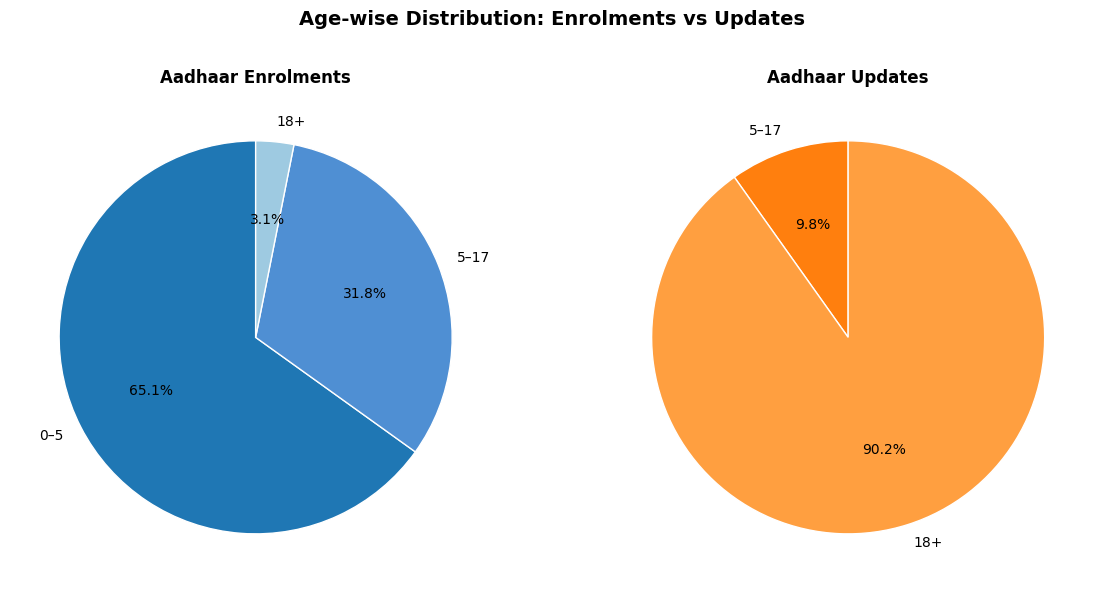

In [12]:
# ============================================================================
# SECTION 6: DEMOGRAPHIC ANALYSIS 
# ============================================================================
''' Identify which age groups dominate enrolments and updates.'''

def plot_age_distribution_comparison(
    enrol_df,
    update_df,
    enrol_title='Enrolments',
    update_title='Updates'
):
    enrol_age_cols = ['age_0_5', 'age_5_17', 'age_18_greater']
    update_age_cols = ['demo_age_5_17', 'demo_age_17_']

    enrol_totals = enrol_df[enrol_age_cols].sum()
    update_totals = update_df[update_age_cols].sum()

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(
        'Age-wise Distribution: Enrolments vs Updates',
        fontsize=14,
        fontweight='bold'
    )

    # Enrolment pie
    axes[0].pie(
        enrol_totals,
        labels=['0–5', '5–17', '18+'],
        autopct='%1.1f%%',
        startangle=90,
        colors=COLOR_CONFIG['enrol']['age_colors'],
        wedgeprops={'edgecolor': 'white'}
    )
    axes[0].set_title(enrol_title, fontweight='bold')

    # Update pie
    axes[1].pie(
        update_totals,
        labels=['5–17', '18+'],
        autopct='%1.1f%%',
        startangle=90,
        colors=COLOR_CONFIG['update']['age_colors'],
        wedgeprops={'edgecolor': 'white'}
    )
    axes[1].set_title(update_title, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# Age-wise Distribution: Enrolments vs Updates
plot_age_distribution_comparison(
    enrol_df=enrol_clean,
    update_df=update_clean,
    enrol_title='Aadhaar Enrolments',
    update_title='Aadhaar Updates'
)

Business Insight: Age-wise analysis revealed a clear distinction between Aadhaar enrolment and update behavior. Approximately 65% of enrolments were contributed by children aged 0–5 years, indicating strong early-life Aadhaar adoption. In contrast, over 90% of Aadhaar update transactions originated from adults aged 18 years and above, highlighting that Aadhaar maintenance activities are predominantly driven by the adult population. This suggests that enrolment initiatives are primarily focused on onboarding new beneficiaries, whereas update infrastructure is mainly utilized for maintaining existing records.

Recommendation 1 -
For enrolments:Continue strengthening child enrolment programs through hospitals, birth registration centers, and educational institutions.
Recommendation 2 -
For updates:Increase update service capacity in regions with high adult populations, as adults account for the majority of Aadhaar update demand.
Recommendation 3 -
For UIDAI Planning:Resource allocation strategies should differentiate between enrolment-focused and update-focused service centers, as the two activities serve distinct demographic segments.

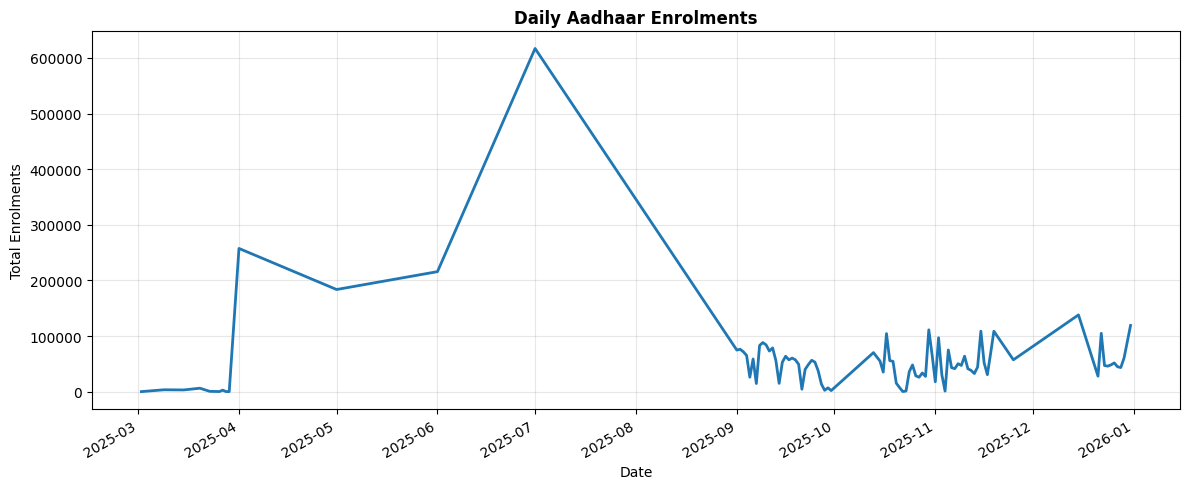

In [14]:
# ============================================================================
# SECTION 7: TREND ANALYSIS
# ============================================================================
'''To observe how enrolment and update counts vary across different month.'''

def plot_daily_trend(df, metric_col, dataset_type, title):
    if dataset_type not in COLOR_CONFIG:
        raise ValueError(
            f"Invalid dataset_type '{dataset_type}'. "
            f"Expected one of {list(COLOR_CONFIG.keys())}"
        )

    daily = (
        df.groupby('date')[metric_col]
        .sum()
        .sort_index()
    )

    # ✅ Explicitly extract primary color
    color = COLOR_CONFIG[dataset_type]['primary']

    plt.figure(figsize=(12, 5))
    daily.plot(
        color=color,
        linewidth=2
    )

    plt.title(title, fontweight='bold')
    plt.xlabel("Date")
    plt.ylabel(metric_col.replace('_', ' ').title())
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Daily Aadhaar Enrolments
plot_daily_trend(
    df=enrol_clean,
    metric_col='total_enrolments',
    dataset_type='enrol',
    title='Daily Aadhaar Enrolments'
)

Interpretation of the July 1, 2025 Spike
- Cause: The spike was triggered by CBDT’s regulation mandating real‑time Aadhaar authentication for new PAN card issuance.
- Immediate Effect: A surge in enrolment/authentication activity as individuals rushed to comply with the new requirement.
  
System Impact:
- Increased load on Aadhaar authentication infrastructure.
- Higher demand for enrolment/update centers.
- Potential rise in error/rejection rates due to sudden volume.
- Policy Insight: Regulatory changes directly influence Aadhaar usage patterns. This demonstrates how Aadhaar is tightly coupled with other governance systems (tax compliance, financial identity).
- Predictive Indicator: Similar spikes can be anticipated whenever Aadhaar is linked to new entitlements or compliance requirements (e.g., subsidies, voting, banking).

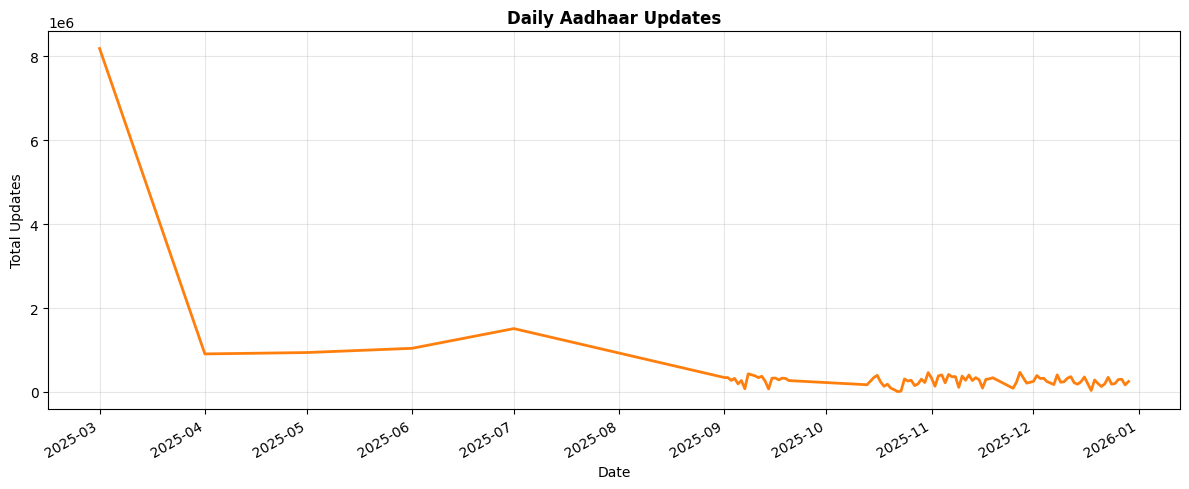

In [16]:
# UPDATE DAILY TRENDS
plot_daily_trend(
    df=update_clean,
    metric_col='total_updates',
    dataset_type='update',
    title='Daily Aadhaar Updates'
)

<Figure size 1200x500 with 0 Axes>

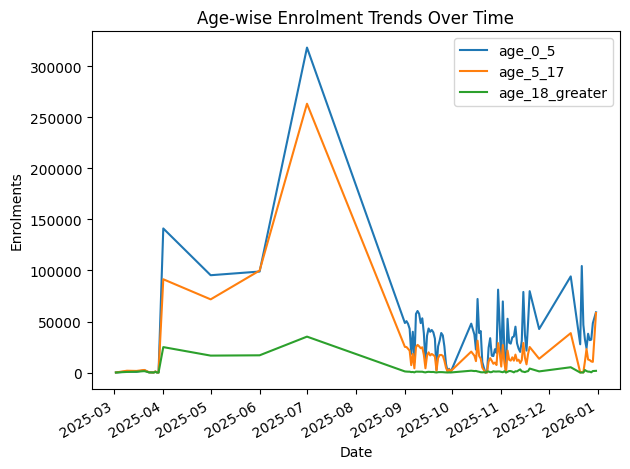

In [17]:
# Enrol - Age * date
age_time = (
    enrol_clean.groupby('date')[['age_0_5','age_5_17','age_18_greater']]
    .sum()
)

plt.figure(figsize=(12,5))
age_time.plot()
plt.title("Age-wise Enrolment Trends Over Time")
plt.ylabel("Enrolments")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

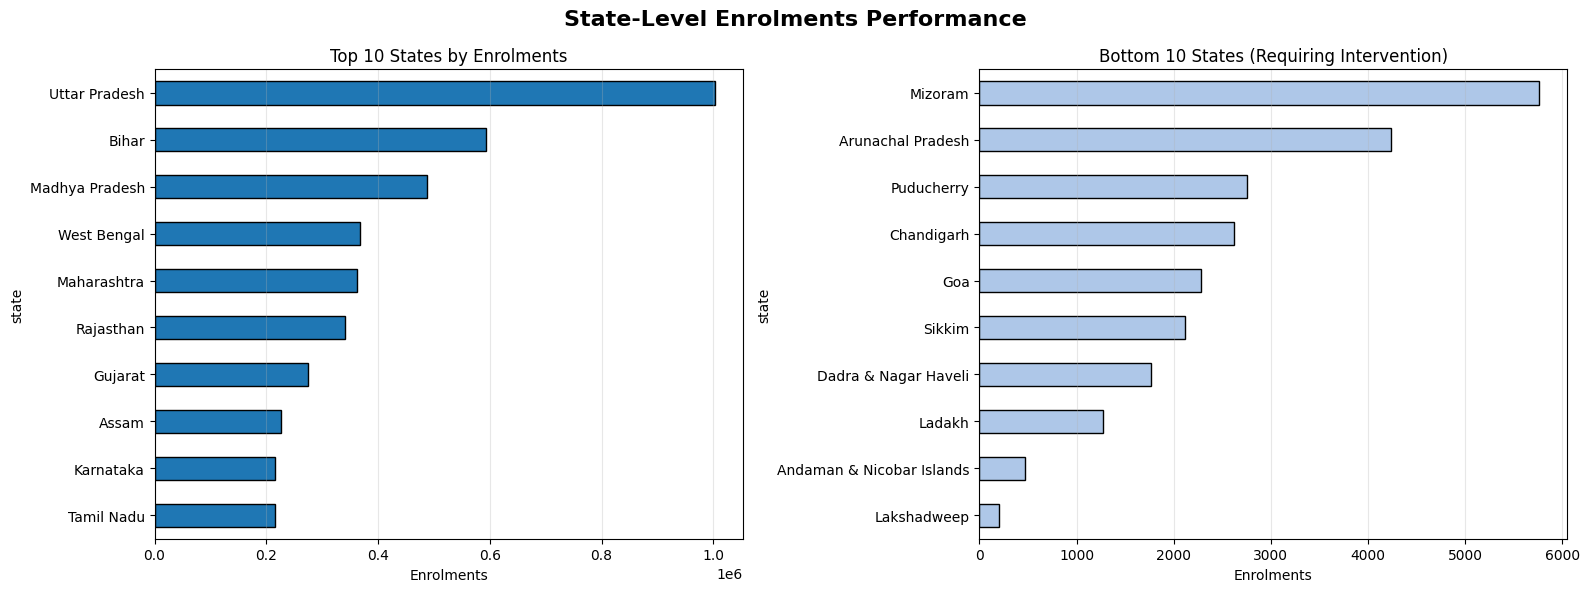


KEY INSIGHTS:
• Uttar Pradesh leads with 1,002,436 enrolments
• Lakshadweep has only 199 enrolments
• Gap ratio: 5037.4x
• 25 states below national average


In [18]:
# ============================================================================
# SECTION 8: GEOGRAPHIC DISTRIBUTION - STATE-LEVEL PERFORMANCE
# ============================================================================
'''Shows which states are performing well vs struggling. IMPACT: Resource allocation and best practice sharing'''

def state_level_summary(
    df,
    metric_col,
    dataset_type,   # 'enrol' or 'update'
    dataset_label,  # for titles only
    age_cols=None,
    top_n=10
):
    colors = COLOR_CONFIG[dataset_type]

    # ----------------------------
    # Aggregation logic
    # ----------------------------
    agg_dict = {
        metric_col: ['sum', 'mean', 'count']
    }

    if age_cols:
        for col in age_cols:
            agg_dict[col] = 'sum'

    state_summary = (
        df.groupby('state')
        .agg(agg_dict)
        .round(2)
    )

    # Flatten column names
    new_cols = [
        'Total_Value', 'Avg_Per_Record', 'Record_Count'
    ]

    if age_cols:
        new_cols += [f"{col}_Total" for col in age_cols]

    state_summary.columns = new_cols

    state_summary = state_summary.sort_values(
        'Total_Value', ascending=False
    )

    # ----------------------------
    # Top / Bottom States
    # ----------------------------
    top_states = state_summary.head(top_n)
    bottom_states = state_summary.tail(top_n)

    # ----------------------------
    # Visualization
    # ----------------------------
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f"State-Level {dataset_label} Performance",
        fontsize=16, fontweight='bold'
    )

    top_states['Total_Value'].plot(
        kind='barh', ax=axes[0],color=colors['primary'],edgecolor='black'
    )
    axes[0].set_title(
        f"Top {top_n} States by {dataset_label}"
    )
    axes[0].set_xlabel(dataset_label)
    axes[0].invert_yaxis()
    axes[0].grid(True, axis='x', alpha=0.3)

    bottom_states['Total_Value'].plot(
        kind='barh', ax=axes[1],color=colors['secondary'],edgecolor='black'
    )
    axes[1].set_title(
        f"Bottom {top_n} States (Requiring Intervention)"
    )
    axes[1].set_xlabel(dataset_label)
    axes[1].invert_yaxis()
    axes[1].grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Insight generation
    # ----------------------------
    top_state = state_summary.index[0]
    bottom_state = state_summary.index[-1]
    gap_ratio = (
        state_summary.iloc[0]['Total_Value'] /
        max(state_summary.iloc[-1]['Total_Value'], 1)
    )

    print("\nKEY INSIGHTS:")
    print(
        f"• {top_state} leads with "
        f"{state_summary.iloc[0]['Total_Value']:,.0f} {dataset_label.lower()}"
    )
    print(
        f"• {bottom_state} has only "
        f"{state_summary.iloc[-1]['Total_Value']:,.0f} {dataset_label.lower()}"
    )
    print(f"• Gap ratio: {gap_ratio:.1f}x")
    print(
        f"• {len(state_summary[state_summary['Total_Value'] < state_summary['Total_Value'].mean()])} "
        f"states below national average"
    )

    return state_summary

# State-Level Enrolments Performance
enrol_state_summary = state_level_summary(
    df=enrol_clean,
    metric_col='total_enrolments',
    dataset_type='enrol',
    dataset_label='Enrolments',
    age_cols=['age_0_5', 'age_5_17', 'age_18_greater']
)

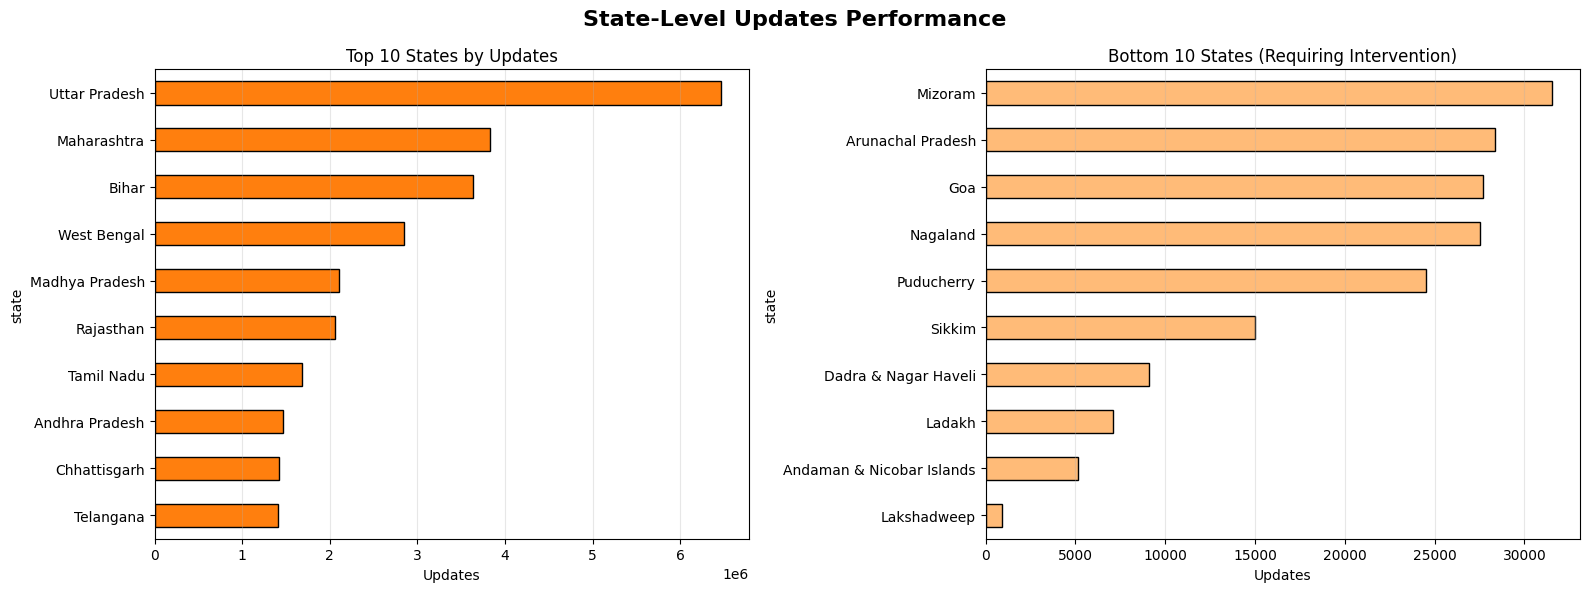


KEY INSIGHTS:
• Uttar Pradesh leads with 6,460,338 updates
• Lakshadweep has only 913 updates
• Gap ratio: 7075.9x
• 23 states below national average


In [19]:
# State-Level Updates Performance
update_state_summary = state_level_summary(
    df=update_clean,
    metric_col='total_updates',
    dataset_type='update',
    dataset_label='Updates',
    age_cols=['demo_age_5_17','demo_age_17_']
)

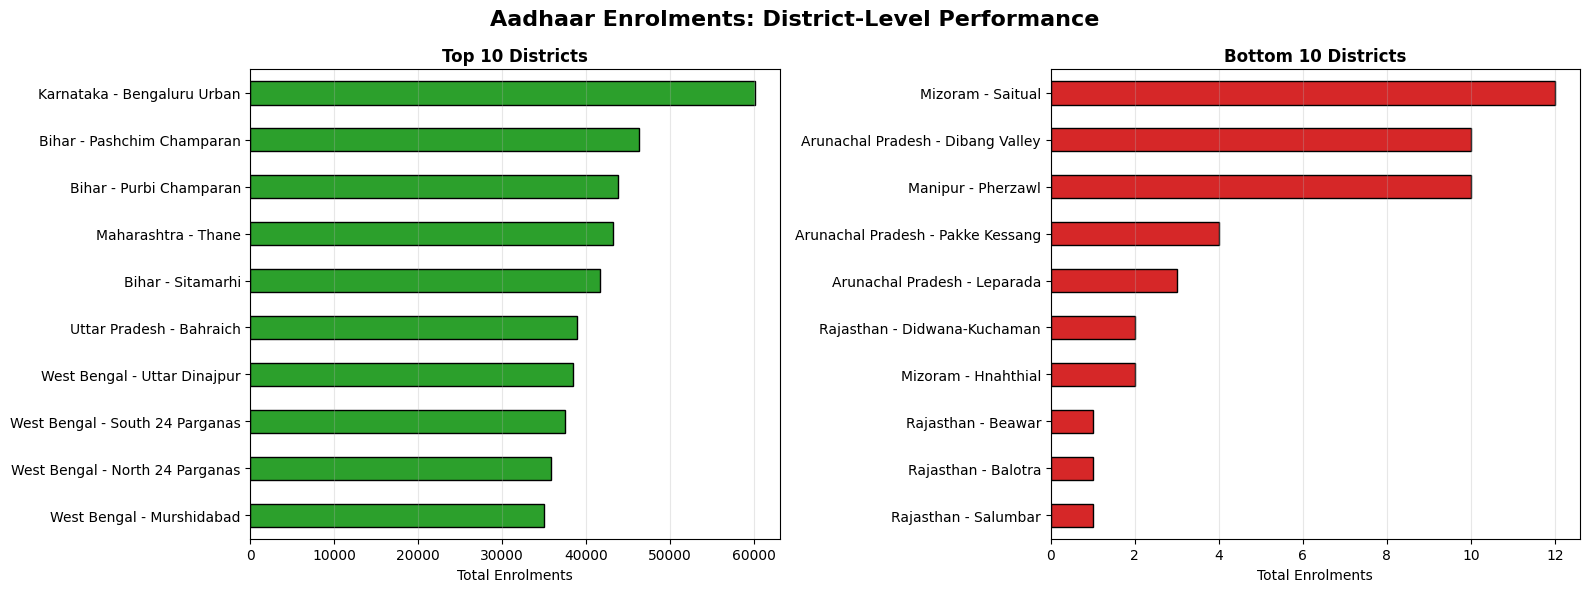

In [20]:
# ============================================================================
# SECTION 9: GEOGRAPHIC DISTRIBUTION - DISTRICT LEVEL PERFORMANCE
# ============================================================================
''' Assess district-wise performance through standalone enrolment and update metrics to identify trends and anomalies.'''

def plot_district_performance(
    df,
    metric_col,
    dataset_type,
    title_prefix,
    top_n=10
):
    import pandas as pd

    if dataset_type not in COLOR_CONFIG:
        raise ValueError(
            f"Invalid dataset_type '{dataset_type}'. "
            f"Expected one of {list(COLOR_CONFIG.keys())}"
        )

    if not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas DataFrame")

    # Aggregate
    district_metric = (
        df.groupby(['state', 'district'])[metric_col]
          .sum()
          .sort_values(ascending=False)
    )

    # Create labels "State - District"
    district_metric.index = [
        f"{s} - {d}" for s, d in district_metric.index
    ]

    top_districts = district_metric.head(top_n)
    bottom_districts = district_metric.tail(top_n)

    colors = COLOR_CONFIG[dataset_type]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f'{title_prefix}: District-Level Performance',
        fontsize=16,
        fontweight='bold'
    )

    # Top districts
    top_districts.plot(
        kind='barh',
        ax=axes[0],
        color=colors['top'],
        edgecolor='black'
    )
    axes[0].set_title(f'Top {top_n} Districts', fontweight='bold')
    axes[0].set_xlabel(metric_col.replace('_', ' ').title())
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3, axis='x')

    # Bottom districts
    bottom_districts.plot(
        kind='barh',
        ax=axes[1],
        color=colors['bottom'],
        edgecolor='black'
    )
    axes[1].set_title(f'Bottom {top_n} Districts', fontweight='bold')
    axes[1].set_xlabel(metric_col.replace('_', ' ').title())
    axes[1].invert_yaxis()
    axes[1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

    return top_districts, bottom_districts

# Enrolment District Performance
top_enrol_districts, bottom_enrol_districts = plot_district_performance(
    df=enrol_clean,
    metric_col='total_enrolments',
    dataset_type='enrol',
    title_prefix='Aadhaar Enrolments'
)

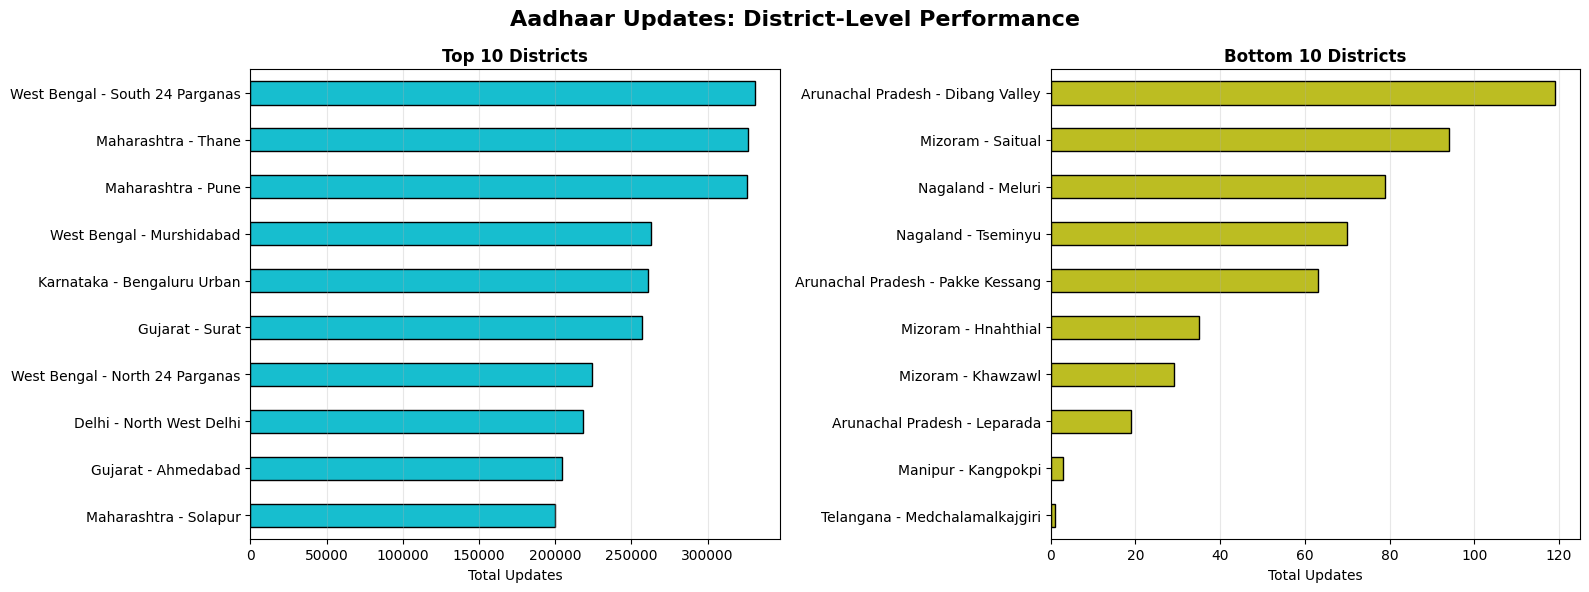

In [21]:
# Update District Performance
top_update_districts, bottom_update_districts = plot_district_performance(
    df=update_clean,
    metric_col='total_updates',
    dataset_type='update',
    title_prefix='Aadhaar Updates'
)

In [22]:
# ============================================================================
# SECTION 10: Create STATE MONTH DATASET
# ============================================================================
''' Used for anomaly detection,Compare enrolments and updates at the same aggregation level.'''

state_month_enrol = (
    enrol_clean
    .groupby(
        ['state','month']
    )
    ['total_enrolments']
    .sum()
    .reset_index()
)

state_month_updates = (
    update_clean
    .groupby(
        ['state','month']
    )
    ['total_updates']
    .sum()
    .reset_index()
)

# Merge
state_month = pd.merge(
    state_month_enrol,
    state_month_updates,
    on=['state','month'],
    how='outer'
)

state_month.fillna(0,inplace=True)

,state,month,total_enrolments,total_updates
0,Andaman & Nicobar Islands,3,0.0,931.0
1,Andaman & Nicobar Islands,7,0.0,219.0
2,Andaman & Nicobar Islands,9,177.0,757.0
3,Andaman & Nicobar Islands,10,74.0,540.0
4,Andaman & Nicobar Islands,11,103.0,1131.0
...,...,...,...,...
292,West Bengal,7,28544.0,110830.0
293,West Bengal,9,119046.0,660929.0
294,West Bengal,10,72889.0,402280.0
295,West Bengal,11,78487.0,619850.0


In [23]:
# Create Update Rate
''' Update Rate is a derived metric representing the ratio of Aadhaar update transactions to Aadhaar enrolment transactions within a geographic region
and time period. It serves as an indicator of Aadhaar record maintenance activity and helps identify regions exhibiting unusually high or 
low update behavior relative to enrolment activity.This is a defensible metric for anomaly detection, state comparison, clustering, 
and policy recommendations'''

state_month['update_rate'] = (
    state_month['total_updates']
    /
    state_month['total_enrolments']
    .replace(0,np.nan)
)

state_month['update_rate'] = (
    state_month['update_rate']
    .fillna(0)
)

state_month.head()

,state,month,total_enrolments,total_updates,update_rate
0,Andaman & Nicobar Islands,3,0.0,931.0,0.000000
1,Andaman & Nicobar Islands,7,0.0,219.0,0.000000
2,Andaman & Nicobar Islands,9,177.0,757.0,4.276836
3,Andaman & Nicobar Islands,10,74.0,540.0,7.297297
4,Andaman & Nicobar Islands,11,103.0,1131.0,10.980583


Business Interpretation:

1. Low Update Rate: Many new enrolments, Fewer updates.
    - Possible reasons: New Aadhaar adoption region, Young population, Recently enrolled population.
2. Moderate Update Rate: Balanced enrolment and update activity.This usually indicates a stable Aadhaar ecosystem.
3. High Update Rate: Updates exceed enrolments.
    - Possible reasons: Address changes, Mobile number updates, Population mobility, Mature Aadhaar ecosystem.  
4. Total enrolments alone only tell:How many people enrolled.
5. Total updates alone only tell:How many updates occurred.
6. But update_rate tells:How actively Aadhaar records are being maintained relative to new enrolments.

In [25]:
# ============================================================================
# SECTION 11: STATISTICAL ANOMALY DETECTION
# ============================================================================
''' Applied Interquartile Range (IQR) analysis to detect states exhibiting unusually high or low Aadhaar update activity. '''

Q1 = state_month['update_rate'].quantile(0.25)
Q3 = state_month['update_rate'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

anomalies = state_month[
    (state_month['update_rate'] < lower)
    |
    (state_month['update_rate'] > upper)
]

anomalies.shape

(35, 5)

In [26]:
# ============================================================================
# SECTION 12: ISOLATION FOREST - UNSUPERVISED ANOMALY DETECTION
# ============================================================================

# Select Features
features = state_month[
    [
        'total_enrolments',
        'total_updates',
        'update_rate'
    ]
]

# Scale Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    features
)

# Train Isolation Forest
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

state_month['anomaly'] = (
    iso.fit_predict(
        scaled_features
    )
)

# Extract Anomalous state
anomalous_states = (
    state_month[
        state_month['anomaly'] == -1
    ]
)

anomalous_states.shape

(15, 6)

In [27]:
# Anomaly Score
state_month['anomaly_score'] = (
    iso.decision_function(
        scaled_features
    )
)
state_month.sort_values('anomaly_score').head(10)

,state,month,total_enrolments,total_updates,update_rate,anomaly,anomaly_score
275,Uttar Pradesh,9,260997.0,1150652.0,4.408679,-1,-0.180279
228,Rajasthan,3,94.0,845740.0,8997.234043,-1,-0.177372
244,Tamil Nadu,3,34.0,382485.0,11249.558824,-1,-0.172058
116,Jharkhand,3,55.0,405756.0,7377.381818,-1,-0.134010
270,Uttar Pradesh,3,5393.0,1619359.0,300.270536,-1,-0.118620
277,Uttar Pradesh,11,178330.0,1124622.0,6.306409,-1,-0.118358
278,Uttar Pradesh,12,114377.0,1460587.0,12.769936,-1,-0.110275
167,Maharashtra,11,70877.0,1519364.0,21.436630,-1,-0.109177
35,Bihar,9,143559.0,980081.0,6.827026,-1,-0.065370
288,West Bengal,3,121.0,417606.0,3451.289256,-1,-0.054639


In [28]:
# Anomaly Detection Comparison

# create statelist
iqr_states = set(anomalies['state'])
iso_states = set(anomalous_states['state'])

# find common anomalies
common_states = iqr_states.intersection(iso_states)
print("Common anomalies:", len(common_states))

# IQR only
iqr_only = iqr_states - iso_states
print("IQR only anomalies:", len(iqr_only))

# Isolation Forest only
iso_only = iso_states - iqr_states
print("Isolation Forest only anomalies:", len(iso_only))

Common anomalies: 8
IQR only anomalies: 14
Isolation Forest only anomalies: 0


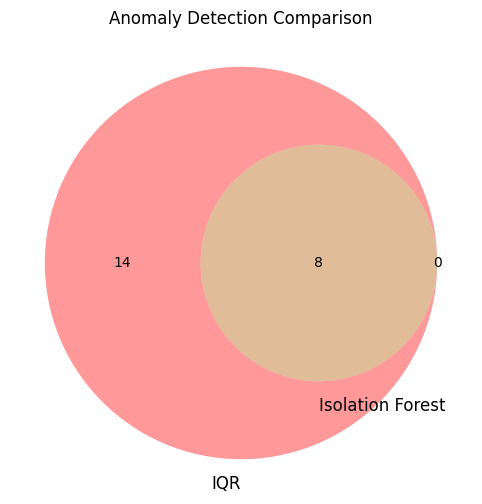

In [29]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
venn2(
    [iqr_states, iso_states],
    set_labels=('IQR','Isolation Forest')
)

plt.title('Anomaly Detection Comparison')
plt.show()

Although Isolation Forest was implemented to detect multivariate anomalies, the analysis revealed that all machine learning-detected anomalies were already captured by the IQR method. This indicates that Aadhaar enrolment-update anomalies in the dataset are primarily explained by extreme values in individual behavioural metrics. Therefore, statistical anomaly detection proved highly effective and interpretable for this use case.
The 8 common states should be treated as High Confidence Anomalies because both methods agree.The remaining 14 IQR-only states should be treated as Moderate Anomalies because only statistical evidence supports them.

In [31]:
# ============================================================================
# SECTION 13: K-MEANS SEGMENTATION
# ============================================================================
'''With K-Means we can find which states behave similar Aadhaar service utilization patterns, enabling differentiated resource planning
and policy interventions.'''

# Create State Profile Dataset for K-Means
state_profile = (
    state_month
    .groupby('state')
    .agg({
        'total_enrolments':'sum',
        'total_updates':'sum'
    })
    .reset_index()
)

state_profile['update_rate'] = (
    state_profile['total_updates']
    /
    state_profile['total_enrolments']
)

# Select Features
features = state_profile[
    [
        'total_enrolments',
        'total_updates',
        'update_rate'
    ]
]

# Scale Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


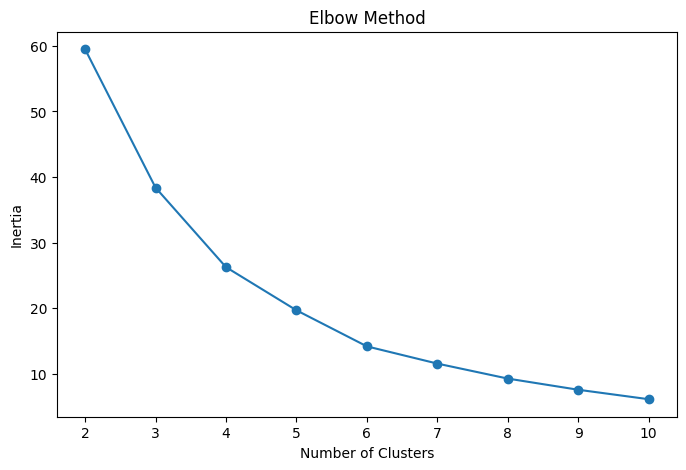

In [32]:
# Find Optimal Number of Clusters (Elbow Method)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [33]:
# Train K-Means

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

state_profile['cluster'] = (
    kmeans.fit_predict(
        scaled_features
    )
)

# View Results
state_profile.sort_values(
    'cluster'
)

,state,total_enrolments,total_updates,update_rate,cluster
0,Andaman & Nicobar Islands,471.0,5142.0,10.917197,0
2,Arunachal Pradesh,4240.0,28391.0,6.695991,0
3,Assam,225493.0,755027.0,3.348339,0
7,Dadra & Nagar Haveli,1762.0,9085.0,5.156073,0
12,Himachal Pradesh,16905.0,115781.0,6.848920,0
11,Haryana,95083.0,825843.0,8.685496,0
10,Gujarat,274897.0,1358036.0,4.940163,0
8,Delhi,92836.0,969666.0,10.444935,0
14,Jharkhand,153418.0,1065118.0,6.942588,0
13,Jammu & Kashmir,46885.0,292042.0,6.228901,0


In [34]:
# Cluster summary
cluster_summary = (
    state_profile
    .groupby('cluster')
    .agg({
        'total_enrolments':'mean',
        'total_updates':'mean',
        'update_rate':'mean',
        'state':'count'
    })
    .rename(
        columns={'state':'num_states'}
    )
)

print(cluster_summary)

         total_enrolments  total_updates  update_rate  num_states
cluster                                                          
0                77561.88   4.979633e+05     6.786964          25
1               525792.50   3.488009e+06     6.867625           6
2                44942.00   6.403052e+05    15.935858           5


K-Means clustering segmented states into three operational categories. 
- Cluster 0 represents Balanced Aadhaar Activity States exhibiting moderate service utilization.
- Cluster 1 consists of High Aadhaar Demand States characterized by the highest enrolment and update volumes.
- Cluster 2 comprises Update-Dominant States where update activity significantly exceeds new enrolment demand, indicating mature Aadhaar ecosystems with higher maintenance and demographic update requirements.

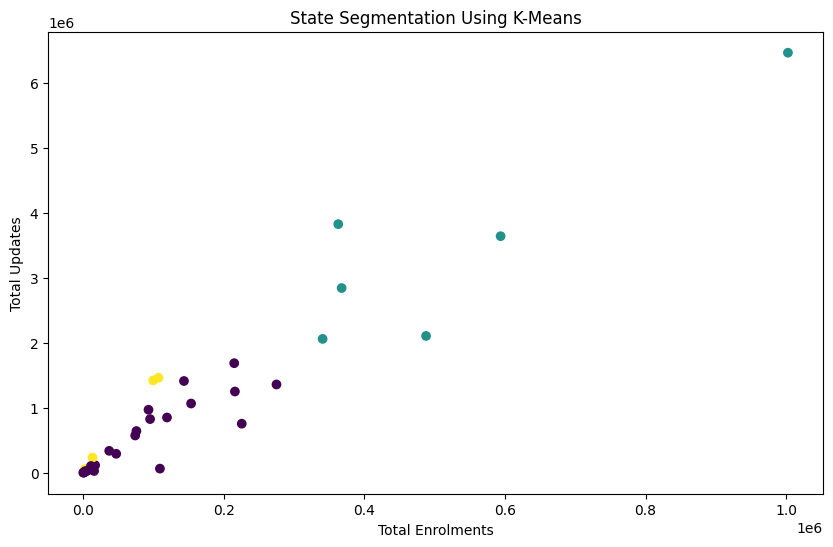

In [36]:
# visualize clusters

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    state_profile['total_enrolments'],
    state_profile['total_updates'],
    c=state_profile['cluster']
)

plt.xlabel('Total Enrolments')
plt.ylabel('Total Updates')
plt.title('State Segmentation Using K-Means')

plt.show()

The cluster assignments are not determined solely by the visual proximity of points in the two-dimensional scatter plot. K-Means performs clustering using all selected features in the multidimensional feature space. While the visualization displays only two variables (Total Enrolments and Total Updates), the clustering model was trained using three features: Total Enrolments, Total Updates, and Update Rate. Therefore, points that appear close in the 2D visualization may belong to different clusters due to differences in the third feature, which is not visible in the plot.

In [38]:
# ============================================================================
# SECTION 14: PREDICTIVE INDICATOR
# ============================================================================

# Update Rate Indicator

state_enrol = (
    enrol_clean
    .groupby('state')['total_enrolments']
    .sum()
    .reset_index()
)

state_update = (
    update_clean
    .groupby('state')['total_updates']
    .sum()
    .reset_index()
)

state_indicator = pd.merge(
    state_enrol,
    state_update,
    on='state',
    how='outer'
).fillna(0)

state_indicator['update_rate'] = (
    state_indicator['total_updates'] /
    state_indicator['total_enrolments']
)

state_indicator.sort_values(
    'update_rate',
    ascending=False
).head(10)

,state,total_enrolments,total_updates,update_rate
5,Chandigarh,2617,57375,21.923959
21,Manipur,13199,233382,17.681794
6,Chhattisgarh,99633,1421244,14.264792
1,Andhra Pradesh,106981,1461836,13.664445
9,Goa,2280,27689,12.144298
0,Andaman & Nicobar Islands,471,5142,10.917197
20,Maharashtra,362773,3824045,10.541151
8,Delhi,92836,969666,10.444935
31,Telangana,143301,1411412,9.849282
32,Tripura,11006,104568,9.500999


Decision Framework
| Update Rate | Action                         |
| ----------- | ------------------------------ |
| >10         | Increase update infrastructure |
| 5-10        | Maintain current capacity      |
| <5          | Focus on enrolment expansion   |


In [40]:
# Child Dependency Indicator
child_indicator = (
    enrol_clean
    .groupby('state')
    .agg({
        'age_0_5':'sum',
        'age_18_greater':'sum'
    })
    .reset_index()
)

child_indicator['child_dependency_ratio'] = (
    child_indicator['age_0_5'] /
    child_indicator['age_18_greater']
)

child_indicator.sort_values(
    'child_dependency_ratio',
    ascending=False
).head(10)

,state,age_0_5,age_18_greater,child_dependency_ratio
0,Andaman & Nicobar Islands,439,0,inf
18,Lakshadweep,188,1,188.000000
30,Tamil Nadu,177375,1202,147.566556
25,Odisha,96227,726,132.544077
31,Telangana,114877,1148,100.067073
34,Uttarakhand,31194,338,92.289941
12,Himachal Pradesh,16077,178,90.320225
11,Haryana,85111,1076,79.099442
13,Jammu & Kashmir,38744,520,74.507692
5,Chandigarh,2374,33,71.939394


Interpretation: States with large child enrolment populations will generate future biometric update demand.
- High ratio → Future update demand likely
- Low ratio → Mature enrolment profile

In [42]:
# Monthly Growth Indicator - Positive growth → Rising enrolment activity.Negative growth → Declining activity
monthly_enrolments = (
    enrol_clean
    .groupby('month')['total_enrolments']
    .sum()
    .reset_index()
)

monthly_enrolments['growth_rate'] = (
    monthly_enrolments['total_enrolments']
    .pct_change() * 100
)

monthly_enrolments


,month,total_enrolments,growth_rate
0,3,16582,NaN
1,4,257438,1452.514775
2,5,183616,-28.675642
3,6,215734,17.491940
4,7,616868,185.939166
5,9,1471293,138.510184
6,10,776922,-47.194610
7,11,1049249,35.052039
8,12,730810,-30.349231


In [43]:
# Update Burden Indicator
''' Measures operational pressure from update requests.'''

state_indicator['update_burden'] = (
    state_indicator['total_updates']
    /
    (
        state_indicator['total_updates']
        +
        state_indicator['total_enrolments']
    )
)

state_indicator.sort_values(
    'update_burden',
    ascending=False
).head(10)

,state,total_enrolments,total_updates,update_rate,update_burden
5,Chandigarh,2617,57375,21.923959,0.956378
21,Manipur,13199,233382,17.681794,0.946472
6,Chhattisgarh,99633,1421244,14.264792,0.934490
1,Andhra Pradesh,106981,1461836,13.664445,0.931808
9,Goa,2280,27689,12.144298,0.923921
0,Andaman & Nicobar Islands,471,5142,10.917197,0.916088
20,Maharashtra,362773,3824045,10.541151,0.913354
8,Delhi,92836,969666,10.444935,0.912625
31,Telangana,143301,1411412,9.849282,0.907828
32,Tripura,11006,104568,9.500999,0.904771


Decision Framework
| Update Burden | Action                     |
| ------------- | -------------------------- |
| High          | Update-focused services    |
| Medium        | Balanced services          |
| Low           | Enrolment-focused services |


This project analyzed Aadhaar enrolment and update datasets to uncover demographic, geographic, and operational patterns that can support data-driven decision-making within the Aadhaar ecosystem. The analysis combined exploratory data analysis, trend analysis, anomaly detection, state segmentation, and predictive indicators to identify meaningful societal trends and service utilization patterns.